# S6E4 — Predicting Irrigation Need
**Task**: Multiclass classification → `Irrigation_Need` (Low / Medium / High)  
**Metric**: Balanced Accuracy Score  
**Deadline**: April 30, 2026

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
np.random.seed(42)

print("Libraries loaded.")

Libraries loaded.


## Load Data

In [2]:
# Environment-aware path switching
is_kaggle = os.path.exists("/kaggle/input")
input_dir = "/kaggle/input/competitions/playground-series-s6e4" if is_kaggle else "./data"
output_dir = "/kaggle/working" if is_kaggle else "./submissions"

print(f"Environment: {'Kaggle' if is_kaggle else 'Local'}")
print(f"Input dir : {input_dir}")
print(f"Output dir: {output_dir}")

train_df = pd.read_csv(f"{input_dir}/train.csv")
test_df  = pd.read_csv(f"{input_dir}/test.csv")

print(f"\nTrain shape: {train_df.shape}")
print(f"Test shape : {test_df.shape}")
train_df.head(3)

Environment: Local
Input dir : ./data
Output dir: ./submissions

Train shape: (630000, 21)
Test shape : (270000, 20)


,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low


## Exploratory Data Analysis

In [4]:
TARGET = "Irrigation_Need"

# Target distribution
print("=== Target distribution ===")
vc = train_df[TARGET].value_counts()
print(vc)
print(f"\nClass balance (%):\n{(vc / len(train_df) * 100).round(2)}")

# Missing values
print("\n=== Missing values (train) ===")
missing = train_df.isnull().sum()
print(missing[missing > 0] if missing.any() else "None")

# Dtypes summary
print("\n=== Column dtypes ===")
print(train_df.dtypes.value_counts())

# Feature types
def is_categorical(series):
    return series.dtype == "object" or hasattr(series.dtype, "name") and series.dtype.name in ("string", "str")

cat_features = [c for c in train_df.columns if c not in [TARGET, "id"] and is_categorical(train_df[c])]
num_features = [c for c in train_df.columns if c not in [TARGET, "id"] and not is_categorical(train_df[c])]
print(f"\nCategorical features ({len(cat_features)}): {cat_features}")
print(f"Numeric features   ({len(num_features)}): {num_features}")

=== Target distribution ===
Irrigation_Need
Low       369917
Medium    239074
High       21009
Name: count, dtype: int64

Class balance (%):
Irrigation_Need
Low       58.72
Medium    37.95
High       3.33
Name: count, dtype: float64

=== Missing values (train) ===
None

=== Column dtypes ===
float64    11
str         9
int64       1
Name: count, dtype: int64

Categorical features (8): ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']
Numeric features   (11): ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']


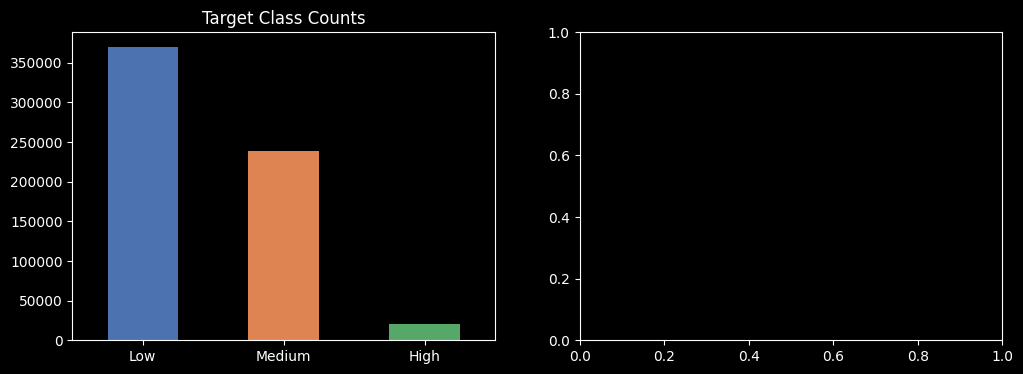

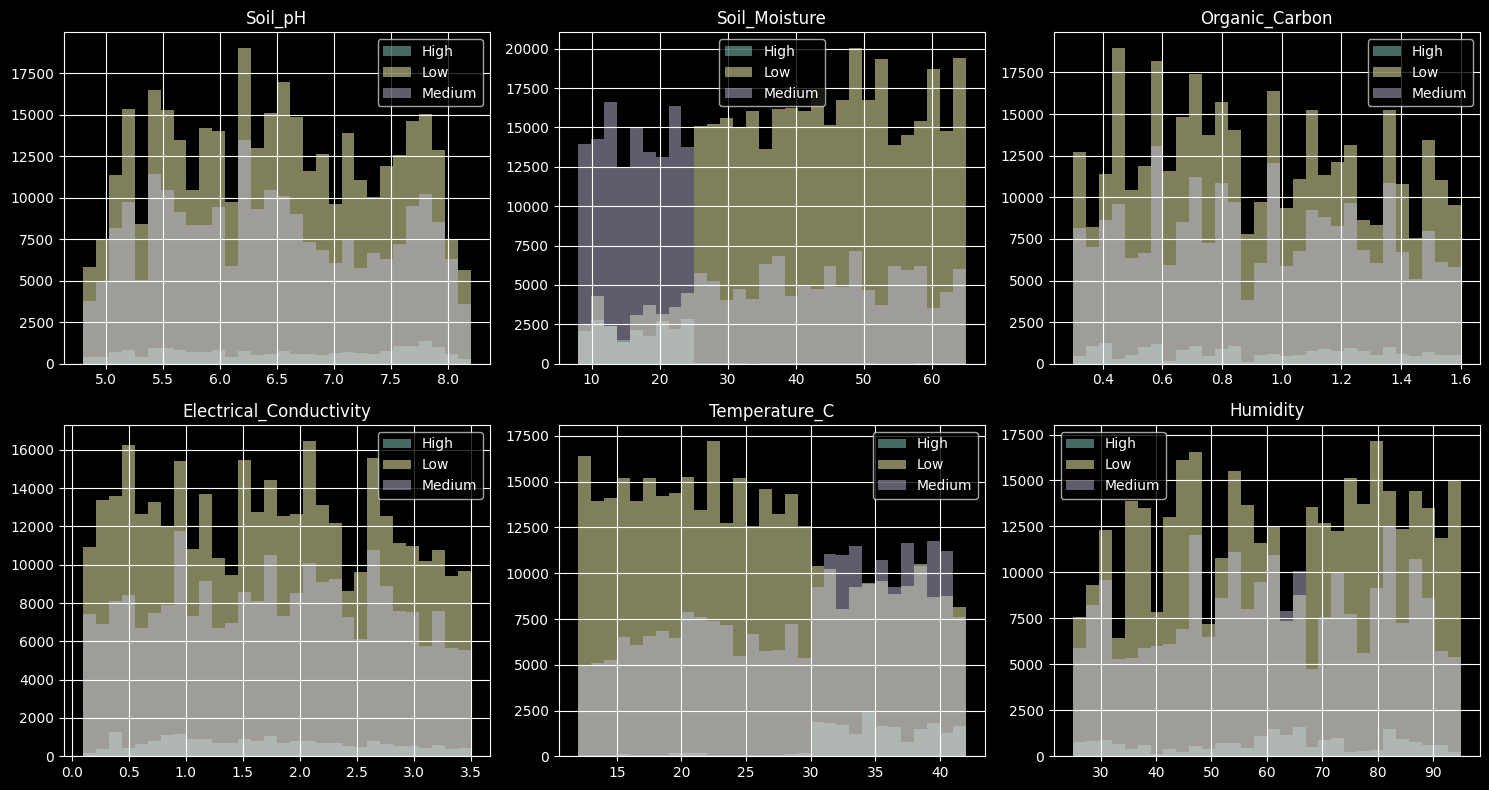

<Figure size 640x480 with 0 Axes>

In [5]:
# Target distribution bar plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
vc.plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452", "#55A868"])
axes[0].set_title("Target Class Counts")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)

# Numeric feature distributions (first 6)
if num_features:
    cols_to_plot = num_features[:6]
    fig2, axes2 = plt.subplots(2, 3, figsize=(15, 8))
    for i, col in enumerate(cols_to_plot):
        ax = axes2[i // 3][i % 3]
        for label, grp in train_df.groupby(TARGET):
            grp[col].hist(ax=ax, alpha=0.5, bins=30, label=label)
        ax.set_title(col)
        ax.legend()
    plt.tight_layout()
    plt.show()

plt.tight_layout()
plt.show()

## Preprocessing & Feature Engineering

In [6]:
# ---- Target encoding ----
# Ordered by natural irrigation need level
CLASS_ORDER = ["Low", "Medium", "High"]
label_map   = {c: i for i, c in enumerate(CLASS_ORDER)}
inv_label_map = {i: c for c, i in label_map.items()}

y = train_df[TARGET].map(label_map).astype(int)
print("Target encoded:", label_map)
print(y.value_counts().sort_index())

# ---- Build feature matrix ----
drop_cols = [TARGET, "id"]
all_features = [c for c in train_df.columns if c not in drop_cols]

X_train_raw = train_df[all_features].copy()
X_test_raw  = test_df[[c for c in all_features if c in test_df.columns]].copy()

# Re-identify cat/num after subsetting
cat_features = [c for c in all_features if is_categorical(X_train_raw[c])]
num_features = [c for c in all_features if not is_categorical(X_train_raw[c])]

# ---- Label-encode categorical ----
le_dict = {}
for col in cat_features:
    le = LabelEncoder()
    combined = pd.concat([X_train_raw[col], X_test_raw[col]], axis=0).astype(str)
    le.fit(combined)
    X_train_raw[col] = le.transform(X_train_raw[col].astype(str))
    X_test_raw[col]  = le.transform(X_test_raw[col].astype(str))
    le_dict[col] = le

# ---- Scale numeric ----
scaler = StandardScaler()
X_train_raw[num_features] = scaler.fit_transform(X_train_raw[num_features])
X_test_raw[num_features]  = scaler.transform(X_test_raw[num_features])

X_train = X_train_raw.values
X_test  = X_test_raw.values
n_classes = len(CLASS_ORDER)

print(f"\nX_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Classes: {n_classes}")

Target encoded: {'Low': 0, 'Medium': 1, 'High': 2}
Irrigation_Need
0    369917
1    239074
2     21009
Name: count, dtype: int64


ValueError: could not convert string to float: 'Loamy'

## Model Training
5-fold StratifiedKFold CV with LightGBM, XGBoost, and CatBoost. OOF predictions stored for leakage-safe ensemble.

In [ ]:
def build_lgb(n_classes):
    return lgb.LGBMClassifier(
        n_estimators=800,
        learning_rate=0.05,
        num_leaves=63,
        max_depth=-1,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        objective="multiclass",
        num_class=n_classes,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )

def build_xgb(n_classes):
    return xgb.XGBClassifier(
        n_estimators=800,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        objective="multi:softprob",
        num_class=n_classes,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1,
        verbosity=0,
    )

def build_cat(n_classes, cat_idx):
    return CatBoostClassifier(
        iterations=600,
        learning_rate=0.05,
        depth=6,
        loss_function="MultiClass",
        eval_metric="Accuracy",
        auto_class_weights="Balanced",
        cat_features=cat_idx if cat_idx else None,
        random_seed=42,
        verbose=0,
    )

print("Model builders defined.")

In [ ]:
def run_cv(model_fn, X, y, X_test, n_classes, n_folds=5, name="model"):
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    oof_proba  = np.zeros((len(X), n_classes))
    test_proba = np.zeros((len(X_test), n_classes))
    scores = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr, y_val = y.values[tr_idx], y.values[val_idx]

        model = model_fn()
        model.fit(X_tr, y_tr)

        val_pred  = model.predict_proba(X_val)
        oof_proba[val_idx] = val_pred
        test_proba += model.predict_proba(X_test) / n_folds

        fold_pred_labels = np.argmax(val_pred, axis=1)
        score = balanced_accuracy_score(y_val, fold_pred_labels)
        scores.append(score)
        print(f"  Fold {fold+1}: {score:.5f}")

    oof_labels = np.argmax(oof_proba, axis=1)
    overall = balanced_accuracy_score(y.values, oof_labels)
    print(f"  [{name}] OOF Balanced Accuracy: {overall:.5f}  (mean folds: {np.mean(scores):.5f})")
    return oof_proba, test_proba, overall

print("CV helper defined.")

In [ ]:
print("=== LightGBM ===")
lgb_oof, lgb_test, lgb_score = run_cv(
    lambda: build_lgb(n_classes), X_train, y, X_test, n_classes, name="LGB"
)

print("\n=== XGBoost ===")
xgb_oof, xgb_test, xgb_score = run_cv(
    lambda: build_xgb(n_classes), X_train, y, X_test, n_classes, name="XGB"
)

print("\n=== CatBoost ===")
# CatBoost can use original integer-encoded cat features
cat_idx = list(range(len(cat_features)))  # first N columns are cats after our encoding
cat_oof, cat_test, cat_score = run_cv(
    lambda: build_cat(n_classes, cat_idx), X_train, y, X_test, n_classes, name="CAT"
)

print(f"\nSummary: LGB={lgb_score:.5f}, XGB={xgb_score:.5f}, CAT={cat_score:.5f}")

## Model Evaluation

In [ ]:
# CV score bar chart
model_names  = ["LGB", "XGB", "CAT"]
model_scores = [lgb_score, xgb_score, cat_score]

plt.figure(figsize=(7, 4))
bars = plt.bar(model_names, model_scores, color=["#4C72B0", "#DD8452", "#55A868"])
plt.ylim(min(model_scores) - 0.01, max(model_scores) + 0.01)
for bar, sc in zip(bars, model_scores):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
             f"{sc:.5f}", ha="center", va="bottom", fontsize=10)
plt.title("OOF Balanced Accuracy by Model")
plt.ylabel("Balanced Accuracy")
plt.tight_layout()
plt.show()

In [ ]:
# Confusion matrix for best single model
best_oof = lgb_oof if lgb_score >= max(xgb_score, cat_score) else (xgb_oof if xgb_score >= cat_score else cat_oof)
best_name = model_names[model_scores.index(max(model_scores))]

cm = confusion_matrix(y.values, np.argmax(best_oof, axis=1))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_ORDER)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"OOF Confusion Matrix — {best_name}")
plt.tight_layout()
plt.show()

# Feature importance (LGB)
feat_names = all_features
lgb_model_final = build_lgb(n_classes)
lgb_model_final.fit(X_train, y)
importances = pd.Series(lgb_model_final.feature_importances_, index=feat_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.head(20).plot(kind="bar")
plt.title("LGB Feature Importances (top 20)")
plt.tight_layout()
plt.show()

## OOF-Safe Ensemble
Average the OOF probabilities from all three models weighted by their OOF scores, then use a Ridge meta-learner on top.

In [ ]:
# Simple weighted average by OOF score
total_score = lgb_score + xgb_score + cat_score
w_lgb = lgb_score / total_score
w_xgb = xgb_score / total_score
w_cat = cat_score / total_score

blend_oof  = w_lgb * lgb_oof  + w_xgb * xgb_oof  + w_cat * cat_oof
blend_test = w_lgb * lgb_test + w_xgb * xgb_test + w_cat * cat_test

blend_score = balanced_accuracy_score(y.values, np.argmax(blend_oof, axis=1))
print(f"Weights → LGB: {w_lgb:.3f}, XGB: {w_xgb:.3f}, CAT: {w_cat:.3f}")
print(f"Blended OOF Balanced Accuracy: {blend_score:.5f}")

# Stack OOF probabilities as meta-features for Ridge
meta_train = np.hstack([lgb_oof, xgb_oof, cat_oof])
meta_test  = np.hstack([lgb_test, xgb_test, cat_test])

from sklearn.linear_model import LogisticRegression as LR
meta_model = LR(C=1.0, max_iter=1000, random_state=42, class_weight="balanced", multi_class="auto")

# OOF evaluation of the meta-model (leakage-safe via skf)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
meta_oof_pred = np.zeros(len(y))

for tr_idx, val_idx in skf.split(meta_train, y):
    meta_model.fit(meta_train[tr_idx], y.values[tr_idx])
    meta_oof_pred[val_idx] = meta_model.predict(meta_train[val_idx])

meta_score = balanced_accuracy_score(y.values, meta_oof_pred)
print(f"Meta-LR  OOF Balanced Accuracy: {meta_score:.5f}")

# Fit on full data for final test predictions
meta_model.fit(meta_train, y)
meta_test_pred = meta_model.predict(meta_test)
meta_test_proba = meta_model.predict_proba(meta_test)

## Generate Submission

In [ ]:
os.makedirs(output_dir, exist_ok=True)

# Pick best prediction: meta-LR if it beats blend, else blend
if meta_score >= blend_score:
    final_test_labels = [inv_label_map[p] for p in meta_test_pred]
    chosen = "meta-LR"
else:
    final_test_labels = [inv_label_map[p] for p in np.argmax(blend_test, axis=1)]
    chosen = "weighted blend"

print(f"Using: {chosen}  (meta={meta_score:.5f}, blend={blend_score:.5f})")

sub = pd.DataFrame({
    "id": test_df["id"],
    "Irrigation_Need": final_test_labels
})

out_path = f"{output_dir}/submission.csv"
sub.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(sub["Irrigation_Need"].value_counts())
sub.head()